In [2]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install pyro-ppl seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import pandas as pd
import pyro
import pyro.distributions as dist
from pyro.infer import MCMC, NUTS
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from devinterp.optim.sgld import SGLD
from devinterp.optim.sgnht import SGNHT
from devinterp.slt import estimate_learning_coeff_with_summary, sample
from devinterp.slt.llc import LLCEstimator, SamplerCallback, OnlineLLCEstimator
from devinterp.utils import plot_trace

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
sns.set_style("whitegrid")

# plotting
CMAP = sns.color_palette("muted", as_cmap=True)
PRIMARY, SECONDARY, TERTIARY = CMAP[:3]

/var/folders/ds/qvg7h1s93x16vvczwp8vr83m0000gn/T/ipykernel_17947/2903749014.py:4: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd
/Users/ragharao/opt/anaconda3/envs/devinterp_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# constants
SIGMA = 0.25
NUM_TRAIN_SAMPLES = 1000
BATCH_SIZE = NUM_TRAIN_SAMPLES
CRITERION = F.mse_loss

In [4]:
class SingularModel(nn.Module):
    def __init__(self, powers):
        super(SingularModel, self).__init__()
        self.weights = nn.Parameter(
            torch.tensor([0.0, 0.0], dtype=torch.float32, requires_grad=True).to(DEVICE)
        )
        self.powers = powers

    def forward(self, x):
        multiplied = torch.prod(self.weights**self.powers)
        x = x * multiplied
        return x

def generate_dataset_for_seed(seed=0):
    torch.manual_seed(seed)
    np.random.seed(seed)
    x = torch.normal(0, 2, size=(NUM_TRAIN_SAMPLES,))
    y = SIGMA * torch.normal(0, 1, size=(NUM_TRAIN_SAMPLES,))
    train_data = TensorDataset(x, y)
    train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
    return train_loader, train_data, x, y

In [26]:
w = torch.tensor([2.0, 3.0], dtype=torch.float32)
p = torch.tensor([5, 2])

result = torch.prod(w**p)
print(result)

w = torch.tensor([2.0, 3.0], dtype=torch.float32)
p = torch.tensor([0, 2])

result = torch.prod(w**p)
print(result)

tensor(288.)
tensor(9.)


In [7]:
train_loader, train_data, x, y = generate_dataset_for_seed(0)
lr = 0.0001
num_chains = 3
num_draws = 5000
powers_to_test = [
    torch.tensor([0, 2]).to(DEVICE), # minimally singular
    torch.tensor([2, 0]).to(DEVICE) # minimally sigular
]
rlct_estimates_sgld = {
    tuple(power.detach().cpu().tolist()): estimate_learning_coeff_with_summary(
        model=SingularModel(power),
        loader=train_loader,
        optimizer_kwargs=dict(
            lr=lr,
            bounding_box_size=1.0,
        ),
        criterion=CRITERION,
        sampling_method=SGLD,
        num_chains=num_chains,
        num_draws=num_draws,
        device=DEVICE,
        online=True
    )
    for power in powers_to_test
}
rlct_estimates_sgnht = {
    tuple(power.detach().cpu().tolist()): estimate_learning_coeff_with_summary(
        model=SingularModel(power),
        loader=train_loader,
        optimizer_kwargs=dict(
            lr=lr,
            bounding_box_size=1.0,
            diffusion_factor=0.01,
        ),
        criterion=CRITERION,
        sampling_method=SGNHT,
        num_chains=num_chains,
        num_draws=num_draws,
        device=DEVICE,
        online = True
    )
    for power in powers_to_test
}

/Users/ragharao/opt/anaconda3/envs/devinterp_env/lib/python3.11/site-packages/devinterp/slt/sampler.py:170: UserWarning: You are taking more draws than burn-in steps, your LLC estimates will likely be underestimates. Please check LLC chain convergence.
  warnings.warn(
/Users/ragharao/opt/anaconda3/envs/devinterp_env/lib/python3.11/site-packages/devinterp/slt/sampler.py:174: UserWarning: You are taking more sample batches than there are dataloader batches available, this removes some randomness from sampling but is probably fine. (All sample batches beyond the number dataloader batches are cycled from the start, f.e. 9 samples from [A, B, C] would be [B, A, C, B, A, C, B, A, C].)
  warnings.warn(
/Users/ragharao/opt/anaconda3/envs/devinterp_env/lib/python3.11/site-packages/devinterp/slt/sampler.py:58: UserWarning: You are taking more sample batches than there are dataloader batches available, this removes some randomness from sampling but is probably fine. (All sample batches beyond th

In [52]:
for sampler_type, estimates in zip(
    ("sgld", "sgnht"), (rlct_estimates_sgld, rlct_estimates_sgnht)
):
    df_data = {
        "powers": [k for k in estimates.keys()],
        "LLC_Summary": estimates.values(),
    }
    
    df = pd.DataFrame(df_data)
    df["llc_means"] = df["LLC_Summary"].apply(lambda x: x["llc/means"][-100:].mean())
    df["llc_stds"] = df["LLC_Summary"].apply(lambda x: x["llc/stds"][-100:].mean())
    df = df.drop("LLC_Summary", axis=1)
    print(sampler_type)
    print(df.to_string(index=False))
    #print(df["llc_means"])

sgld
powers  llc_means  llc_stds
(0, 2)   0.075753  0.077194
(2, 0)   0.173660  0.165575
sgnht
powers  llc_means  llc_stds
(0, 2)   0.253120  0.293238
(2, 0)   0.160469  0.216324


In [17]:
print(rlct_estimates_sgnht[(0,2)].keys)

dict_keys(['llc/means', 'llc/moving_avg', 'llc/stds', 'llc/trace', 'loss/trace'])


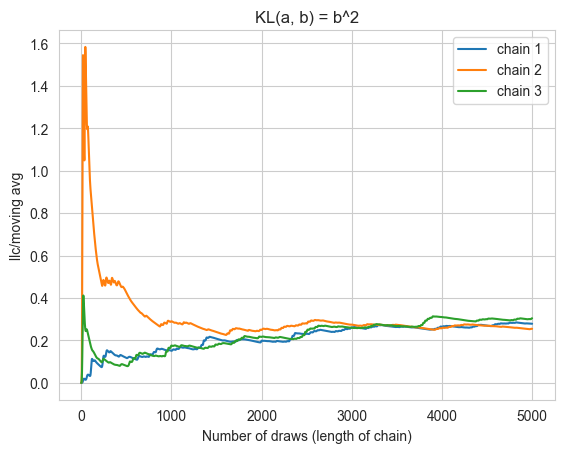

In [54]:
x = [i for i in range(5000)]
y = rlct_estimates_sgnht[(0,2)]['llc/moving_avg']
for i in range(y.shape[0]):
    plt.plot(x, y[i], label = f'chain {i+1}')

plt.xlabel("Number of draws (length of chain)")
plt.ylabel("llc/moving avg")
plt.legend(loc="upper right")
plt.title("KL(a, b) = b^2")

plt.show()

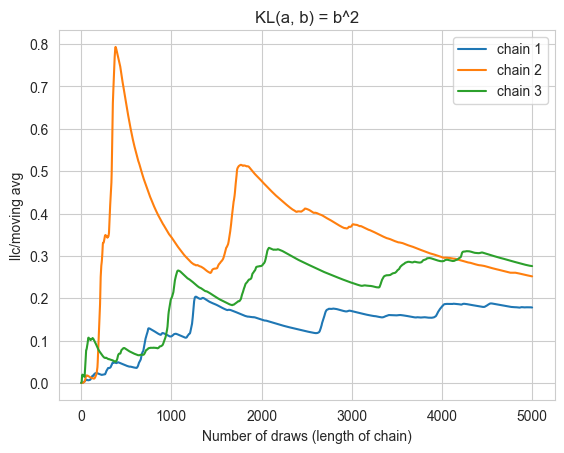

In [55]:
x = [i for i in range(5000)]
y = rlct_estimates_sgld[(0,2)]['llc/moving_avg']
for i in range(y.shape[0]):
    plt.plot(x, y[i], label = f'chain {i+1}')

plt.xlabel("Number of draws (length of chain)")
plt.ylabel("llc/moving avg")
plt.legend(loc="upper right")
plt.title("KL(a, b) = b^2")

plt.show()